# Week 5 Assignment - Text Generation with RNN, LSTM and GRU

**Name:** Parth Moholkar
**Track:** Data Science Internship, Celebal Technologies

## Objective
Compare a Vanilla RNN, an LSTM and a GRU on the same text corpus to see why gated architectures handle sequence data better.

## 1. Imports and Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tf.random.set_seed(42)
np.random.seed(42)
pd.set_option('display.max_colwidth', None)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


## 2. Text Corpus
A short, self-contained corpus is used so the whole notebook trains in seconds even without a GPU. Several lines share words and structure, which gives the next-word prediction task something consistent to pick up on.

In [2]:
corpus_text = """
the sun rises early over the quiet mountains
morning brings a gentle breeze through the trees
birds sing softly as the village wakes up
farmers walk slowly toward the green fields
the river flows gently past the old bridge
children run happily along the narrow path
women carry water from the cool spring
the market fills with fresh fruit and grain
merchants call out prices near the square
smoke rises slowly from the kitchen fires
dogs bark quietly near the wooden gate
the temple bell rings across the valley
travelers rest beneath the old banyan tree
clouds drift lazily above the distant hills
farmers return home before the sun sets
evening arrives with a calm orange sky
lanterns glow softly along the quiet street
families gather warmly around the dinner table
stars appear slowly over the sleeping village
the night grows still beneath the bright moon
"""

print(corpus_text)


the sun rises early over the quiet mountains
morning brings a gentle breeze through the trees
birds sing softly as the village wakes up
farmers walk slowly toward the green fields
the river flows gently past the old bridge
children run happily along the narrow path
women carry water from the cool spring
the market fills with fresh fruit and grain
merchants call out prices near the square
smoke rises slowly from the kitchen fires
dogs bark quietly near the wooden gate
the temple bell rings across the valley
travelers rest beneath the old banyan tree
clouds drift lazily above the distant hills
farmers return home before the sun sets
evening arrives with a calm orange sky
lanterns glow softly along the quiet street
families gather warmly around the dinner table
stars appear slowly over the sleeping village
the night grows still beneath the bright moon



## 3. Tokenization and Sequence Creation
Each line is converted to a sequence of integer tokens, then split into growing n-grams so the model learns to predict the next token at every position in a line, not just the very last word.

In [3]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus_text])
vocab_size = len(tokenizer.word_index) + 1

sequences = []
for line in corpus_text.strip().split("\n"):
    tokens = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(tokens)):
        sequences.append(tokens[:i + 1])

max_sequence_len = max(len(seq) for seq in sequences)
sequences = pad_sequences(sequences, maxlen=max_sequence_len, padding='pre')

X = sequences[:, :-1]
y = sequences[:, -1]

print("Vocabulary size:", vocab_size)
print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 109
X shape: (126, 7)
y shape: (126,)


## 4. Shared Model Builder
One model builds all three, with the recurrent layer as an argument; hence, RNN, LSTM and GRU have the same embedding size and number of hidden units, with the only difference being that each uses one specific layer. The clipnorm=1.0 on the optimizer prevents exploding gradients by limiting the maximum norm of the gradients that are applied during training.

In [4]:
embedding_dim = 50
hidden_units = 128

def build_text_model(recurrent_layer):
    model = models.Sequential([
        layers.Input(shape=(max_sequence_len - 1,)),
        layers.Embedding(vocab_size, embedding_dim),
        recurrent_layer,
        layers.Dense(vocab_size, activation='softmax')
    ])
    model.compile(loss='sparse_categorical_crossentropy',
                  optimizer=tf.keras.optimizers.Adam(clipnorm=1.0),
                  metrics=['accuracy'])
    return model

def make_callback():
    return tf.keras.callbacks.EarlyStopping(monitor='loss', min_delta=1e-3, patience=15, restore_best_weights=True)

## 5. Model A - Vanilla RNN
The baseline model - a single recurrent layer with no gating. It tends to lose track of earlier words as sequences get longer, due to vanishing gradients.

In [5]:
rnn_model = build_text_model(layers.SimpleRNN(hidden_units))
rnn_history = rnn_model.fit(X, y, epochs=400, callbacks=[make_callback()], verbose=0)
print("Vanilla RNN finished after", len(rnn_history.history['loss']), "epochs")

Vanilla RNN finished after 280 epochs


## 6. Model B - LSTM
Adds input, forget and output gates on top of a cell state, which helps it hold onto information over longer sequences than a plain RNN.

In [6]:
lstm_model = build_text_model(layers.LSTM(hidden_units))
lstm_history = lstm_model.fit(X, y, epochs=400, callbacks=[make_callback()], verbose=0)
print("LSTM finished after", len(lstm_history.history['loss']), "epochs")

LSTM finished after 400 epochs


## 7. Model C - GRU
Uses reset and update gates instead of LSTM's three, making it lighter and usually quicker to train while landing on similar results.

In [7]:
gru_model = build_text_model(layers.GRU(hidden_units))
gru_history = gru_model.fit(X, y, epochs=400, callbacks=[make_callback()], verbose=0)
print("GRU finished after", len(gru_history.history['loss']), "epochs")

GRU finished after 305 epochs


## 8. Training Loss and Accuracy Comparison

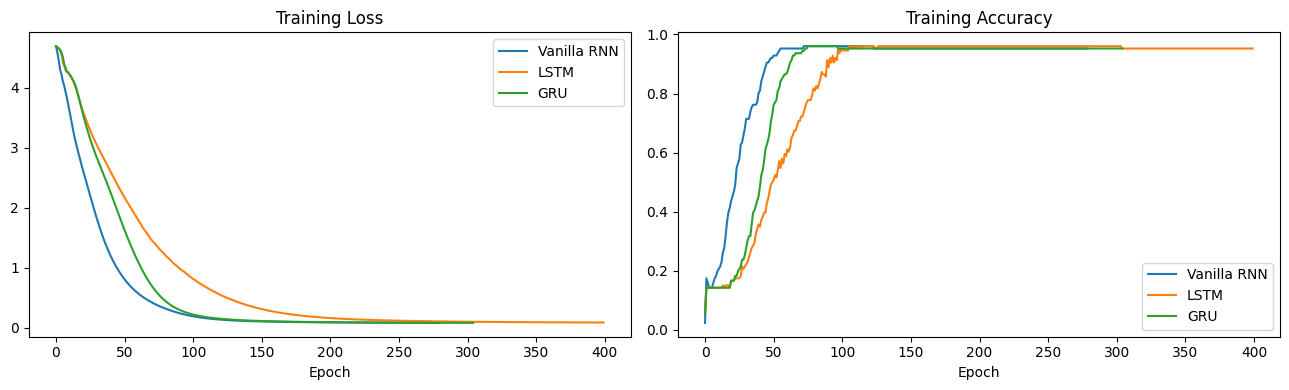

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(rnn_history.history['loss'], label='Vanilla RNN')
axes[0].plot(lstm_history.history['loss'], label='LSTM')
axes[0].plot(gru_history.history['loss'], label='GRU')
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(rnn_history.history['accuracy'], label='Vanilla RNN')
axes[1].plot(lstm_history.history['accuracy'], label='LSTM')
axes[1].plot(gru_history.history['accuracy'], label='GRU')
axes[1].set_title("Training Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

In [9]:
metrics_df = pd.DataFrame({
    "Model": ["Vanilla RNN", "LSTM", "GRU"],
    "Final Training Loss": [rnn_history.history['loss'][-1], lstm_history.history['loss'][-1], gru_history.history['loss'][-1]],
    "Final Training Accuracy": [rnn_history.history['accuracy'][-1], lstm_history.history['accuracy'][-1], gru_history.history['accuracy'][-1]],
    "Perplexity": [np.exp(rnn_history.history['loss'][-1]), np.exp(lstm_history.history['loss'][-1]), np.exp(gru_history.history['loss'][-1])],
    "Epochs to Converge": [len(rnn_history.history['loss']), len(lstm_history.history['loss']), len(gru_history.history['loss'])]
})
metrics_df

,Model,Final Training Loss,Final Training Accuracy,Perplexity,Epochs to Converge
0,Vanilla RNN,0.083116,0.952381,1.086668,280
1,LSTM,0.088733,0.952381,1.092789,400
2,GRU,0.083013,0.952381,1.086556,305


## 9. Text Generation Function
A reverse look up from token index to word is made once, and each prediction step is a dictionary lookup. The next token is sampled from the temperature-scaled distribution rather than deterministically taking the most probable token, and the previously emitted token is forbidden to sample from itself in the next step in order to prevent repetition (which can happen on some training data if the only valid next token was the previous one).


In [10]:
index_to_word = {index: word for word, index in tokenizer.word_index.items()}

def generate_text(model, seed_text, num_words=8, temperature=0.8):
    for _ in range(num_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_sequence_len - 1, padding='pre')
        probs = model.predict(token_list, verbose=0)[0]

        last_word = seed_text.split()[-1]
        last_index = tokenizer.word_index.get(last_word)
        if last_index is not None and last_index < len(probs):
            probs[last_index] = 0.0
        probs = probs / probs.sum()

        scaled_probs = np.log(probs + 1e-8) / temperature
        scaled_probs = np.exp(scaled_probs) / np.sum(np.exp(scaled_probs))
        predicted_index = np.random.choice(len(scaled_probs), p=scaled_probs)
        seed_text += " " + index_to_word.get(predicted_index, "")
    return seed_text

## 10. Generated Text Samples

In [11]:
seed_phrases = ["the sun", "evening arrives", "the market"]

generation_records = []
for seed in seed_phrases:
    generation_records.append({"Seed": seed, "Model": "Vanilla RNN", "Generated Text": generate_text(rnn_model, seed, num_words=8)})
    generation_records.append({"Seed": seed, "Model": "LSTM", "Generated Text": generate_text(lstm_model, seed, num_words=8)})
    generation_records.append({"Seed": seed, "Model": "GRU", "Generated Text": generate_text(gru_model, seed, num_words=8)})

generation_df = pd.DataFrame(generation_records)
generation_df

,Seed,Model,Generated Text
0,the sun,Vanilla RNN,the sun rises early over the quiet mountains slowly across
1,the sun,LSTM,the sun rises early over the quiet mountains village up
2,the sun,GRU,the sun rises early over the quiet mountains up trees
3,evening arrives,Vanilla RNN,evening arrives with a calm orange sky farmers trees slowly
4,evening arrives,LSTM,evening arrives with a calm orange sky from grain wooden
5,evening arrives,GRU,evening arrives with a calm orange sky drift fruit beneath
6,the market,Vanilla RNN,the market fills with fresh fruit and grain moon trees
7,the market,LSTM,the market fills with fresh fruit and grain arrives up
8,the market,GRU,the market fills with fresh fruit and grain and grain


## 11. Conclusion
- Vanilla RNN handles short local patterns but loses earlier context in longer sequences.
- LSTM holds onto long-range dependencies more reliably through its gates and cell state.
- GRU reaches similar results with a simpler, faster-training structure.
- Comparing all three side by side makes the practical difference between plain and gated recurrent networks clear.

## Notes for Reviewer
- No GPU needed - runs in under a minute on CPU.
- Early stopping on training loss is used for all three models instead of a fixed epoch count.